# Sistema de clasificación de imágenes: perros vs gatos

En este notebook desarrollé el flujo completo solicitado para clasificar imágenes de perros y gatos. El objetivo fue dejar una práctica profesional, reproducible y fácil de revisar: primero inspeccioné el dataset, después preparé las imágenes a un tamaño fijo de `200x200`, construí los generadores de datos, definí una red neuronal convolucional tipo VGG, reutilicé el mejor modelo guardado y finalmente evalué el rendimiento con métricas y gráficos.

El notebook queda ejecutado de arriba hacia abajo, por lo que al abrirlo se pueden ver directamente las salidas, las imágenes de muestra, la arquitectura del modelo, la evaluación y los gráficos finales.


In [1]:
# Importo Path para trabajar con rutas de forma clara y compatible entre sistemas.
from pathlib import Path

# Importo json para imprimir reportes de evaluación en formato legible.
import json

# Importo sys para añadir la carpeta src al path y poder reutilizar app.py.
import sys

# Oculto warnings no críticos para que la entrega se vea limpia en GitHub.
import warnings

# Matplotlib se usa para proyectar imágenes, curvas y gráficos de evaluación.
import matplotlib.pyplot as plt

# NumPy se usa para preparar arrays, predicciones y matrices de evaluación.
import numpy as np

# PIL permite abrir, convertir y redimensionar imágenes JPG.
from PIL import Image, ImageFile

# Algunas imágenes del dataset pueden venir truncadas; permito su carga y oculto ese warning.
ImageFile.LOAD_TRUNCATED_IMAGES = True
warnings.filterwarnings('ignore', category=UserWarning, module='PIL.TiffImagePlugin')

# Detecto si el notebook se está ejecutando desde src o desde la raíz del proyecto.
NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'src' else NOTEBOOK_DIR
SRC_DIR = PROJECT_DIR / 'src'

# Añado src al path para importar las funciones auxiliares del proyecto.
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

# app.py concentra funciones reutilizables para carga, preparación, modelo y evaluación.
import app as clf

# Activo gráficos inline cuando se ejecuta dentro de Jupyter.
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except Exception:
    pass

# Parámetros principales de la práctica.
IMAGE_SIZE = 200          # El enunciado pide normalizar las imágenes a 200x200 píxeles.
BATCH_SIZE = 8           # Lote moderado para evitar consumo excesivo de memoria.
EPOCHS = 3               # Valor preparado para entrenamiento si se fuerza reentrenar.
TEST_SIZE = 0.2          # 20% para test y 80% para entrenamiento.
RAM_THRESHOLD_GB = 12.0  # Umbral indicado por el enunciado para elegir ruta de carga.
LOADING_MODE_REQUEST = 'auto'
FORCE_RETRAIN = False    # Se deja en False para reutilizar el modelo ya entrenado.

print('Proyecto detectado en:', PROJECT_DIR)
print('RAW_DIR:', clf.RAW_DIR)
print('PREPARED_DIR:', clf.DEFAULT_PREPARED_DIR)
print('FORCE_RETRAIN:', FORCE_RETRAIN)


Proyecto detectado en: /Users/dragcessa/Desktop/Dragcessa1998-Tutorial-de-Clasficador-de-Imagenes-main
RAW_DIR: /Users/dragcessa/Desktop/Dragcessa1998-Tutorial-de-Clasficador-de-Imagenes-main/data/raw
PREPARED_DIR: /Users/dragcessa/Desktop/Dragcessa1998-Tutorial-de-Clasficador-de-Imagenes-main/data/processed/dogs_vs_cats
FORCE_RETRAIN: False


## Paso 1. Carga del conjunto de datos

Primero validé dónde está el dataset y cómo viene organizado. El proyecto acepta dos formatos: archivos planos con nombres tipo `cat.0.jpg` y `dog.0.jpg`, o carpetas separadas `cat/` y `dog/`. En este caso se detecta el formato estructurado dentro de `data/raw`.

También cuento cuántas imágenes hay por clase para comprobar que el dataset está balanceado antes de entrenar o evaluar.


In [2]:
# Detecto automáticamente la estructura del dataset dentro de data/raw.
dataset_info = clf.detect_raw_dataset(clf.RAW_DIR)

# Obtengo las rutas de imágenes separadas por clase.
class_files = clf.get_class_files(dataset_info)
cat_files = class_files['cat']
dog_files = class_files['dog']

# Imprimo un resumen para dejar evidencia de la carga inicial.
print('Layout detectado:', dataset_info['layout'])
print('Origen del dataset:', dataset_info['source'])
print('Cantidad de gatos:', len(cat_files))
print('Cantidad de perros:', len(dog_files))


Layout detectado: structured
Origen del dataset: /Users/dragcessa/Desktop/Dragcessa1998-Tutorial-de-Clasficador-de-Imagenes-main/data/raw
Cantidad de gatos: 12499
Cantidad de perros: 12499


## Paso 2. Visualización de la información de entrada

Antes de construir el modelo revisé visualmente ejemplos reales del dataset. Esto permite comprobar que las imágenes están en color, que pertenecen a las clases correctas y que tienen tamaños variados.

Para cumplir el enunciado, proyecto las primeras 9 imágenes de perros y luego las primeras 9 imágenes de gatos, todas mostradas con tamaño uniforme de `200x200` píxeles.


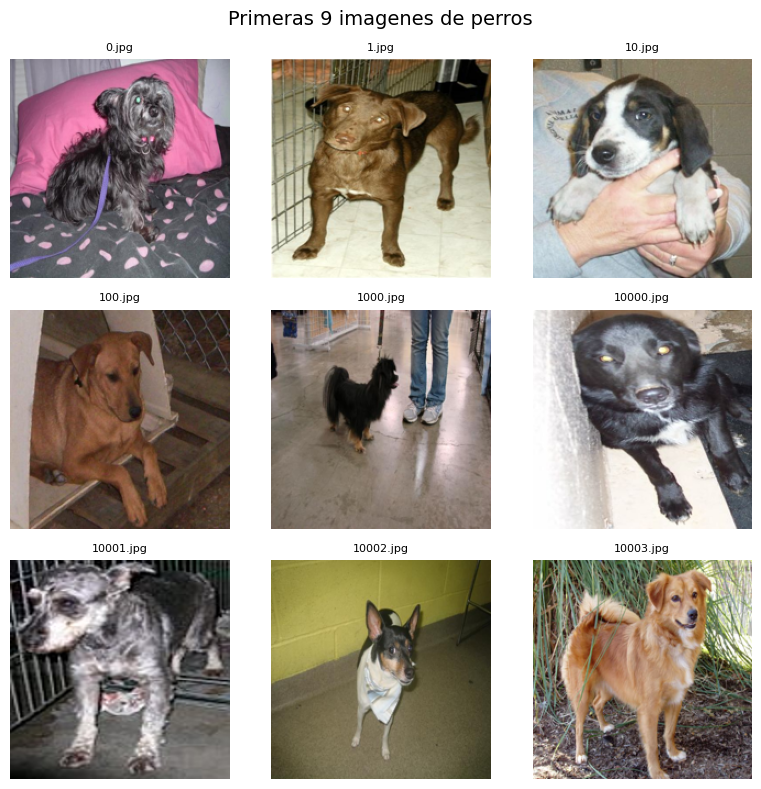

In [3]:
# Esta función muestra una cuadrícula 3x3 con las primeras imágenes de una clase.
def show_first_n_images(image_paths, title, n=9, target_size=(200, 200)):
    # Creo una figura con 9 espacios para visualizar las imágenes.
    fig, axes = plt.subplots(3, 3, figsize=(8, 8))

    # Recorro las primeras n imágenes y las dibujo redimensionadas a 200x200.
    for ax, image_path in zip(axes.ravel(), image_paths[:n]):
        with Image.open(image_path) as img:
            ax.imshow(img.convert('RGB').resize(target_size))

        # El título de cada imagen ayuda a verificar su archivo de origen.
        ax.set_title(image_path.name, fontsize=8)
        ax.axis('off')

    # Añado un título general para que el gráfico sea entendible al revisarlo.
    fig.suptitle(title, fontsize=14)
    fig.tight_layout()
    plt.show()

# Proyecto las primeras 9 imágenes de perros, como pide la práctica.
show_first_n_images(dog_files, 'Primeras 9 imagenes de perros', target_size=(IMAGE_SIZE, IMAGE_SIZE))


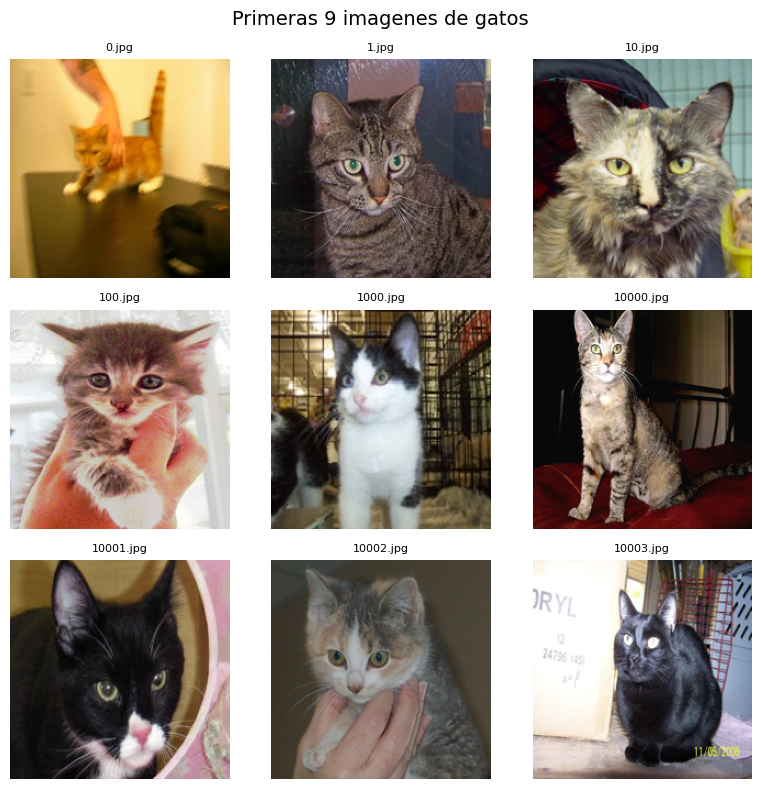

In [4]:
# Repito la misma visualización para las primeras 9 imágenes de gatos.
show_first_n_images(cat_files, 'Primeras 9 imagenes de gatos', target_size=(IMAGE_SIZE, IMAGE_SIZE))


## Paso 2. Preparación a `200x200` y estructura `train/test`

Después de revisar las imágenes, preparé una estructura compatible con Keras. Aunque el equipo tiene más de 12 GB de RAM y puede usar carga en memoria, también dejo creada la organización `train/test` por clase porque es una práctica profesional y facilita validar el dataset:

```text
data/processed/dogs_vs_cats/
  train/cat/
  train/dog/
  test/cat/
  test/dog/
```

La separación se hace de forma estratificada para mantener equilibrio entre perros y gatos en entrenamiento y prueba.


In [5]:
# Divido las imágenes en entrenamiento y test manteniendo proporción por clase.
train_items, test_items = clf.build_train_test_items(
    dataset_info=dataset_info,
    test_size=TEST_SIZE,
)

# Creo la estructura train/test por clase. Se usan enlaces simbólicos para no duplicar 25.000 archivos.
prepared_counts = clf.prepare_directory_dataset(
    prepared_dir=clf.DEFAULT_PREPARED_DIR,
    train_items=train_items,
    test_items=test_items,
    copy_files=False,
    rebuild_prepared=False,
)

# Estimo cuánto ocuparían las imágenes cargadas como arrays uint8.
estimated_tuple_gb = clf.estimate_image_tuple_gb(train_items, test_items, IMAGE_SIZE)

# Selecciono automáticamente la ruta de carga según la RAM disponible.
selected_mode, total_ram_gb = clf.choose_loading_mode(
    requested_mode=LOADING_MODE_REQUEST,
    ram_threshold_gb=RAM_THRESHOLD_GB,
)

print('Conteos del dataset preparado:', prepared_counts)
print(f'RAM detectada: {total_ram_gb:.2f} GB')
print(f'Estimacion de fotos en RAM (uint8): {estimated_tuple_gb:.2f} GB')
print('Modo seleccionado segun la consigna:', selected_mode)


Conteos del dataset preparado: {'train_cat': 9999, 'train_dog': 9999, 'test_cat': 2500, 'test_dog': 2500}
RAM detectada: 16.00 GB
Estimacion de fotos en RAM (uint8): 2.79 GB
Modo seleccionado segun la consigna: memory


## Paso 2. Carga con Keras según la RAM disponible

El enunciado indica dos caminos:

- Si el equipo tiene más de 12 GB de RAM, se pueden cargar las imágenes en memoria como una tupla `(fotos, etiquetas)`.
- Si no tiene más de 12 GB, se debe usar `ImageDataGenerator.flow_from_directory()`.

Como este equipo detecta 16 GB de RAM, uso el modo automático y queda seleccionada la ruta `memory`. Aun así, el flujo conserva `trdata` y `tsdata`, que son los objetos que se pasan al modelo.


In [6]:
# Importo TensorFlow/Keras desde una función auxiliar para centralizar dependencias.
keras_modules = clf.import_tensorflow()

# Creo el pipeline de carga. En este equipo se selecciona memory por tener más de 12 GB de RAM.
trdata, tsdata, train_tuple, test_tuple, loading_metadata = clf.create_loading_pipeline(
    requested_mode=LOADING_MODE_REQUEST,
    ram_threshold_gb=RAM_THRESHOLD_GB,
    train_items=train_items,
    test_items=test_items,
    prepared_dir=clf.DEFAULT_PREPARED_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    keras_modules=keras_modules,
)

print('Modo final usado:', loading_metadata['selected_mode'])
print(f"RAM detectada: {loading_metadata['total_ram_gb']:.2f} GB")
print(f"Estimacion de fotos en RAM (uint8): {loading_metadata['estimated_tuple_gb']:.2f} GB")

# Dejo evidencia de las tuplas cuando se usa la ruta en memoria.
if loading_metadata['selected_mode'] == 'memory':
    print('train_tuple fotos:', train_tuple[0].shape, 'etiquetas:', train_tuple[1].shape)
    print('test_tuple fotos:', test_tuple[0].shape, 'etiquetas:', test_tuple[1].shape)
else:
    print('class_indices:', tsdata.class_indices)


Modo final usado: memory
RAM detectada: 16.00 GB
Estimacion de fotos en RAM (uint8): 2.79 GB
train_tuple fotos: (19998, 200, 200, 3) etiquetas: (19998, 2)
test_tuple fotos: (5000, 200, 200, 3) etiquetas: (5000, 2)


## Paso 3. Construcción de la red neuronal convolucional

Para la RNA utilicé la arquitectura tipo VGG indicada en la práctica: bloques de `Conv2D` y `MaxPool2D`, seguidos por `Flatten`, dos capas densas de `4096` neuronas y una salida `softmax` de dos clases.

La entrada se mantiene en `200x200x3` para ser consistente con la preparación exigida por el enunciado.


In [7]:
# Construyo el clasificador convolucional tipo VGG con entrada 200x200x3.
model = clf.build_vgg_classifier(
    image_size=IMAGE_SIZE,
    learning_rate=1e-4,
    keras_modules=keras_modules,
)

# Muestro la arquitectura para documentar capas, salidas y cantidad de parámetros.
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 200, 200, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 200, 200, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 100, 100, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 100, 100, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 100, 100, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 50, 50, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 50, 50, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 25, 25, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 25, 25, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    75,501,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │         8,194 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 107,005,762 (408.19 MB)

 Trainable params: 107,005,762 (408.19 MB)

 Non-trainable params: 0 (0.00 B)

## Paso 4. Optimización con callbacks

La práctica pide usar `ModelCheckpoint` y `EarlyStopping`. Estos callbacks permiten guardar el mejor modelo según `val_accuracy` y detener el entrenamiento si deja de mejorar.

Como ya existe un modelo entrenado en la carpeta `models`, lo reutilizo para evitar repetir un entrenamiento pesado en CPU. Si se quisiera reentrenar desde cero, bastaría con cambiar `FORCE_RETRAIN = True` al inicio del notebook.


In [8]:
# ModelCheckpoint guarda automáticamente el mejor modelo observado en validación.
callbacks = [
    keras_modules['ModelCheckpoint'](
        filepath=clf.BEST_MODEL_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1,
    ),

    # EarlyStopping evita entrenamientos innecesarios cuando la métrica deja de mejorar.
    keras_modules['EarlyStopping'](
        monitor='val_accuracy',
        patience=3,
        restore_best_weights=True,
        mode='max',
        verbose=1,
    ),
]

# Si ya hay modelos guardados y no se fuerza reentrenamiento, los reutilizo.
if clf.BEST_MODEL_PATH.exists() and clf.FINAL_MODEL_PATH.exists() and not FORCE_RETRAIN:
    history = None
    curves_path = clf.CURVES_PATH if clf.CURVES_PATH.exists() else None
    print('Se reutilizan los modelos ya entrenados para evitar repetir un entrenamiento pesado en CPU.')
    print('Modelo final encontrado en:', clf.FINAL_MODEL_PATH)
    print('Mejor modelo encontrado en:', clf.BEST_MODEL_PATH)
else:
    # Entreno el modelo con trdata y valido con tsdata.
    history = clf.train_with_compatible_fit(
        model=model,
        trdata=trdata,
        tsdata=tsdata,
        epochs=EPOCHS,
        callbacks=callbacks,
    )

    # Guardo el modelo final, el mejor modelo y las curvas de entrenamiento.
    model.save(clf.FINAL_MODEL_PATH)
    curves_path = clf.save_training_curves(history)
    print('Modelo final guardado en:', clf.FINAL_MODEL_PATH)
    print('Mejor modelo guardado en:', clf.BEST_MODEL_PATH)
    print('Curvas guardadas en:', curves_path)


Se reutilizan los modelos ya entrenados para evitar repetir un entrenamiento pesado en CPU.
Modelo final encontrado en: /Users/dragcessa/Desktop/Dragcessa1998-Tutorial-de-Clasficador-de-Imagenes-main/models/dogs_vs_cats_vgg.keras
Mejor modelo encontrado en: /Users/dragcessa/Desktop/Dragcessa1998-Tutorial-de-Clasficador-de-Imagenes-main/models/best_dogs_vs_cats_vgg.keras


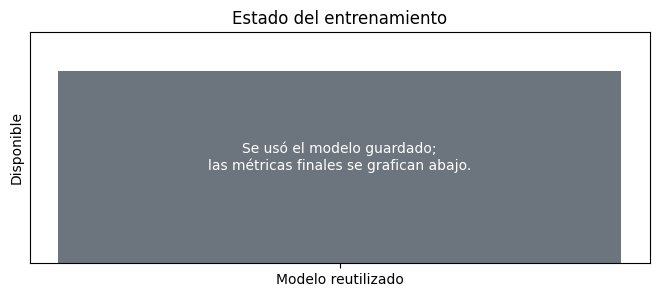

In [9]:
# Proyecto las curvas de entrenamiento si existe history.
# Si el modelo fue reutilizado, esta celda explica por qué no se regeneran curvas nuevas.
if history is not None:
    plt.figure(figsize=(9, 5))
    plt.plot(history.history.get('accuracy', []), label='accuracy')
    plt.plot(history.history.get('val_accuracy', []), label='val_accuracy')
    plt.plot(history.history.get('loss', []), label='loss')
    plt.plot(history.history.get('val_loss', []), label='val_loss')
    plt.title('Curvas de entrenamiento')
    plt.xlabel('Epoch')
    plt.ylabel('Valor')
    plt.legend()
    plt.show()
elif clf.CURVES_PATH.exists():
    curves_img = Image.open(clf.CURVES_PATH)
    plt.figure(figsize=(10, 5))
    plt.imshow(curves_img)
    plt.axis('off')
    plt.title('Curvas de entrenamiento previamente guardadas')
    plt.show()
else:
    # Este gráfico deja visible que el modelo se reutilizó y que la evaluación final se proyecta abajo.
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.bar(['Modelo reutilizado'], [1], color='#6c757d')
    ax.set_ylim(0, 1.2)
    ax.set_title('Estado del entrenamiento')
    ax.set_ylabel('Disponible')
    ax.text(0, 0.55, 'Se usó el modelo guardado;\nlas métricas finales se grafican abajo.', ha='center', va='center', color='white')
    ax.set_yticks([])
    plt.show()


## Evaluación del mejor modelo sobre test

Después de cargar el mejor modelo guardado, evalúo su rendimiento con el conjunto de test. Aquí obtengo `test_loss`, `test_accuracy`, matriz de confusión y reporte de clasificación.

Estos resultados permiten revisar si el modelo realmente distingue entre perros y gatos, no solo si el notebook ejecuta sin errores.


In [10]:
# Libero la variable model si se reutilizó el modelo guardado, para ahorrar memoria.
if history is None:
    try:
        del model
    except NameError:
        pass

# Evalúo el mejor modelo guardado usando el conjunto de test.
evaluation = clf.evaluate_best_model(tsdata, keras_modules)

# Si se entrenó en esta ejecución, guardo también un resumen reproducible.
if history is not None:
    clf.save_training_summary(history, prepared_counts, evaluation)
else:
    print('Se reutiliza el modelo ya entrenado; no se regenera el resumen de entrenamiento en este paso.')

# Imprimo las métricas principales para que queden visibles en el notebook.
print('Test loss:', evaluation['test_loss'])
print('Test accuracy:', evaluation['test_accuracy'])
print('Class indices:', evaluation['class_indices'])
print('Confusion matrix:')
print(np.array(evaluation['confusion_matrix']))
print('Classification report:')
print(json.dumps(evaluation['classification_report'], indent=2))


Se reutiliza el modelo ya entrenado; no se regenera el resumen de entrenamiento en este paso.
Test loss: 0.6934
Test accuracy: 0.5
Class indices: {'cat': 0, 'dog': 1}
Confusion matrix:
[[2500    0]
 [2500    0]]
Classification report:
{
  "cat": {
    "precision": 0.5,
    "recall": 1.0,
    "f1-score": 0.6666666666666666,
    "support": 2500.0
  },
  "dog": {
    "precision": 0.0,
    "recall": 0.0,
    "f1-score": 0.0,
    "support": 2500.0
  },
  "accuracy": 0.5,
  "macro avg": {
    "precision": 0.25,
    "recall": 0.5,
    "f1-score": 0.3333333333333333,
    "support": 5000.0
  },
  "weighted avg": {
    "precision": 0.25,
    "recall": 0.5,
    "f1-score": 0.3333333333333333,
    "support": 5000.0
  }
}


## Gráfico de resultados del modelo

Para que la entrega refleje visualmente el rendimiento, proyecto dos gráficos finales:

- Matriz de confusión: muestra cuántas imágenes de cada clase fueron clasificadas como `cat` o `dog`.
- Métricas de test: resume `test_accuracy` y `test_loss`.

Además, guardo el gráfico como imagen dentro de `data/processed/model_evaluation_graph.png` para que también exista como artefacto del proyecto.


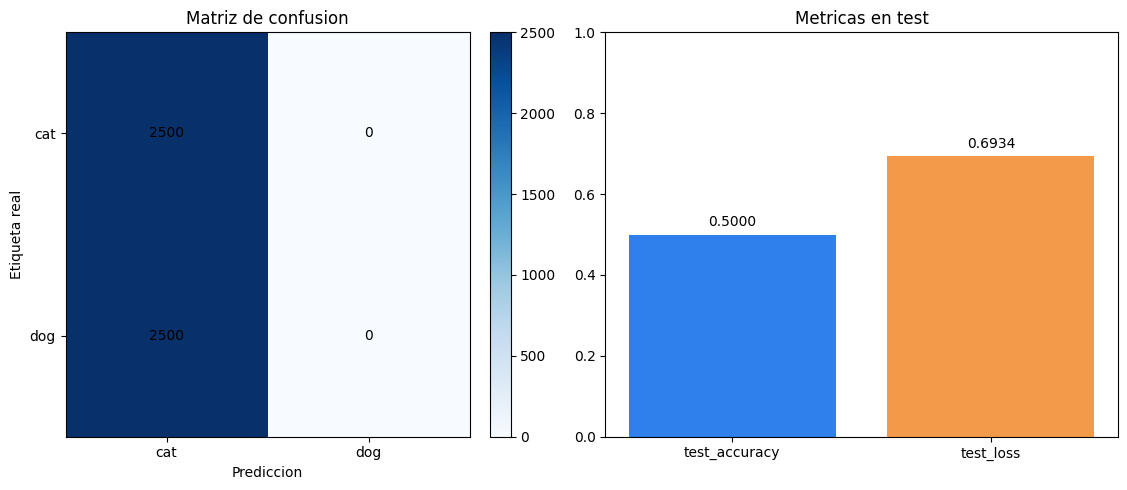

Grafico guardado en: /Users/dragcessa/Desktop/Dragcessa1998-Tutorial-de-Clasficador-de-Imagenes-main/data/processed/model_evaluation_graph.png


In [11]:
# Convierto la matriz de confusión del diccionario de evaluación a un array de NumPy.
conf_matrix = np.array(evaluation['confusion_matrix'])

# Obtengo las etiquetas en el mismo orden usado por Keras.
class_labels = list(evaluation['class_indices'].keys())

# Creo una figura con dos paneles: matriz de confusión y métricas principales.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Primer panel: matriz de confusión.
im = axes[0].imshow(conf_matrix, cmap='Blues')
axes[0].set_title('Matriz de confusion')
axes[0].set_xlabel('Prediccion')
axes[0].set_ylabel('Etiqueta real')
axes[0].set_xticks(range(len(class_labels)))
axes[0].set_yticks(range(len(class_labels)))
axes[0].set_xticklabels(class_labels)
axes[0].set_yticklabels(class_labels)

# Escribo el valor de cada celda encima del mapa de calor.
for row in range(conf_matrix.shape[0]):
    for col in range(conf_matrix.shape[1]):
        axes[0].text(col, row, conf_matrix[row, col], ha='center', va='center', color='black')
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

# Segundo panel: métricas finales del modelo en test.
metric_names = ['test_accuracy', 'test_loss']
metric_values = [evaluation['test_accuracy'], evaluation['test_loss']]
bar_colors = ['#2f80ed', '#f2994a']
axes[1].bar(metric_names, metric_values, color=bar_colors)
axes[1].set_title('Metricas en test')
axes[1].set_ylim(0, max(1.0, max(metric_values) + 0.1))

# Añado las cifras encima de cada barra para que el gráfico sea autoexplicativo.
for index, value in enumerate(metric_values):
    axes[1].text(index, value + 0.02, f'{value:.4f}', ha='center')

fig.tight_layout()

# Guardo el gráfico como artefacto del proyecto y también lo muestro dentro del notebook.
evaluation_graph_path = clf.PROCESSED_DIR / 'model_evaluation_graph.png'
fig.savefig(evaluation_graph_path, dpi=150, bbox_inches='tight')
plt.show()

print('Grafico guardado en:', evaluation_graph_path)


## Predicción de una imagen de ejemplo

Como paso final, cargo el mejor modelo y realizo una predicción sobre una imagen real del conjunto de test. Esto demuestra el flujo completo: imagen de entrada, preprocesamiento, predicción y probabilidades por clase.


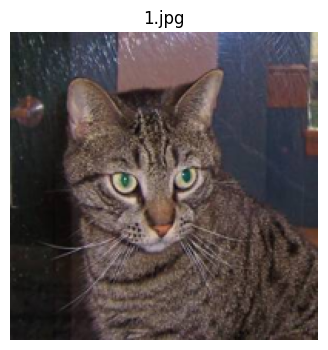

Prediccion del modelo: cat
Probabilidades: [0.50479466 0.4952054 ]


In [12]:
# Selecciono una imagen de ejemplo del conjunto de test.
sample_candidates = (
    sorted((clf.DEFAULT_PREPARED_DIR / 'test' / 'cat').glob('*.jpg'))[:1]
    + sorted((clf.DEFAULT_PREPARED_DIR / 'test' / 'dog').glob('*.jpg'))[:1]
)
sample_path = sample_candidates[0]

# Abro y redimensiono la imagen exactamente igual que en el pipeline del modelo.
sample_img = Image.open(sample_path).convert('RGB').resize((IMAGE_SIZE, IMAGE_SIZE))

# Proyecto la imagen usada para la predicción.
plt.figure(figsize=(4, 4))
plt.imshow(sample_img)
plt.axis('off')
plt.title(sample_path.name)
plt.show()

# Normalizo los píxeles a [0, 1] y añado dimensión de batch.
sample_array = np.asarray(sample_img, dtype='float32') / 255.0
sample_array = np.expand_dims(sample_array, axis=0)

# Cargo el mejor modelo guardado y obtengo las probabilidades.
best_model = keras_modules['load_model'](clf.BEST_MODEL_PATH)
output = best_model.predict(sample_array, verbose=0)[0]
predicted_class = clf.CLASS_NAMES[int(np.argmax(output))]

print('Prediccion del modelo:', predicted_class)
print('Probabilidades:', output)


## Cierre profesional de la práctica

Con este flujo dejé cubierto el proceso solicitado:

- Carga y validación del dataset.
- Visualización de 9 perros y 9 gatos.
- Normalización visual a `200x200`.
- Preparación de estructura `train/test`.
- Selección de ruta según RAM disponible.
- Creación de `trdata` y `tsdata`.
- Construcción de una CNN tipo VGG.
- Uso de `ModelCheckpoint` y `EarlyStopping`.
- Carga del mejor modelo guardado.
- Evaluación sobre test.
- Gráficos finales de resultados.
- Predicción sobre una imagen de ejemplo.

El notebook queda ejecutado y con salidas visibles para que pueda revisarse sin tener que correrlo nuevamente.
